In [1]:
import numpy as np

In [2]:
folder_path = r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\ROAD"

int_id_data = np.load(folder_path + r"\int_id_data.npy", allow_pickle=True)
attack_labels = np.load(folder_path + r"\attack_labels.npy", allow_pickle=True)


int_id_data_test = np.load(folder_path + r"\int_id_data_test.npy", allow_pickle=True)
attack_labels_test = np.load(folder_path + r"\attack_labels_test.npy", allow_pickle=True)

In [3]:
import builtins
import numpy as np


def sliding_windows_id_data(samples, labels, window_size=8, step=2, attack_labels=('T', 'D', 'F', 'S')):
    n = len(samples)

    if isinstance(attack_labels, str):
        attack_labels = (attack_labels,)

    windows = []
    window_labels = []
    next_id_datas = []
    

    for start in range(0, n - window_size, step):
        end = start + window_size
        window_slice = labels[start:end]

        windows.append(samples[start:end])
        next_id_datas.append(samples[end])

        matching_attack = builtins.next(
            (label for label in attack_labels if label in window_slice),
            'R'
        )
        window_labels.append(matching_attack)

    return (
        np.array(windows, dtype=np.uint8),
        np.array(next_id_datas, dtype=object),
        np.array(window_labels, dtype=object)
    )

In [4]:
windows, windowed_labels = [], []
for i in range(len(int_id_data)):
    windows_batch, next_values, windowed_labels_batch = sliding_windows_id_data(int_id_data[i], attack_labels[i])
    windows.extend(windows_batch)
    windowed_labels.extend(windowed_labels_batch)


In [5]:
windowed_labels = np.array(windowed_labels)
attack_onehot = np.zeros((len(windowed_labels), 2), dtype=np.uint8)
attack_onehot[windowed_labels == 'R', 0] = 1
attack_onehot[windowed_labels == 'T', 1] = 1

print(attack_onehot[:10])

[[1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]]


In [6]:
windows_test, windowed_labels_test = [], []
for i in range(len(int_id_data)):
    windows_batch, next_values, windowed_labels_batch = sliding_windows_id_data(int_id_data_test[i], attack_labels_test[i])
    windows_test.extend(windows_batch)
    windowed_labels_test.extend(windowed_labels_batch)

In [7]:
windowed_labels_test = np.array(windowed_labels_test)

attack_onehot_test = np.zeros((len(windowed_labels_test), 2), dtype=np.uint8)
attack_onehot_test[windowed_labels_test == 'R', 0] = 1
attack_onehot_test[windowed_labels_test == 'T', 1] = 1

print(attack_onehot_test[:10])

[[1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]]


In [8]:
windows = np.array(windows)
windows_test = np.array(windows_test)

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=(8,10)), 
    Dense(64, activation="sigmoid"), 
    Dense(32, activation='sigmoid'), 
    Dense(2, activation='softmax'),  
])

c:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ------------------------------------------------------------
# Balance TRAINING windows only
# ------------------------------------------------------------
# Randomly undersample the majority class while keeping each
# window matched to its one-hot label.

train_labels = np.argmax(attack_onehot, axis=1)
train_classes, train_counts = np.unique(train_labels, return_counts=True)
train_minority_count = train_counts.min()

balanced_train_indices = np.concatenate([
    np.random.default_rng(42).choice(
        np.where(train_labels == cls)[0],
        size=train_minority_count,
        replace=False
    )
    for cls in train_classes
])

# Shuffle the selected indices while preserving window/label correspondence.
rng = np.random.default_rng(42)
rng.shuffle(balanced_train_indices)

windows_balanced = windows[balanced_train_indices]
attack_onehot_balanced = attack_onehot[balanced_train_indices]

print('Original training class counts:')
print(dict(zip(train_classes, train_counts)))
print('Balanced training class counts:')
print(dict(zip(*np.unique(np.argmax(attack_onehot_balanced, axis=1), return_counts=True))))
print('Balanced training shape:', windows_balanced.shape)

# ------------------------------------------------------------
# Train using the BALANCED training set
# ------------------------------------------------------------
mod = model.fit(
    windows_balanced,
    attack_onehot_balanced,
    epochs=20,
    batch_size=2000,
    validation_split=0.2
)

print(mod)


Original training class counts:
{0: 2651115, 1: 239355}
Balanced training class counts:
{0: 239355, 1: 239355}
Balanced training shape: (478710, 8, 10)
Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5957 - loss: 0.6640 - val_accuracy: 0.6488 - val_loss: 0.6289
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6820 - loss: 0.5960 - val_accuracy: 0.7056 - val_loss: 0.5681
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7235 - loss: 0.5463 - val_accuracy: 0.7332 - val_loss: 0.5317
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7477 - loss: 0.5134 - val_accuracy: 0.7538 - val_loss: 0.5057
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7637 - loss: 0.4906 - val_accuracy: 0.7655 - val_loss: 0.4874
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7767 - loss: 0.4706 - val_accuracy: 0.7774 - val_loss: 0.4684
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7869 - loss: 0

In [11]:
# ------------------------------------------------------------
# Test 1: ORIGINAL test set - completely unchanged
# ------------------------------------------------------------
loss, accuracy = model.evaluate(windows_test, attack_onehot_test, verbose=0)
print(f'Test loss (original test set): {loss:.4f}')
print(f'Test accuracy (original test set): {accuracy:.4f}')


Test loss (original test set): 0.4046
Test accuracy (original test set): 0.8057


In [12]:
label_map = np.array(['R', 'T'])

def onehot_to_labels(onehot):
    return label_map[np.argmax(onehot, axis=1)]

recovered_labels = onehot_to_labels(model.predict(windows_test, verbose=0))
print(recovered_labels[:20])


['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'T' 'R' 'R' 'R' 'R' 'R'
 'R' 'R']


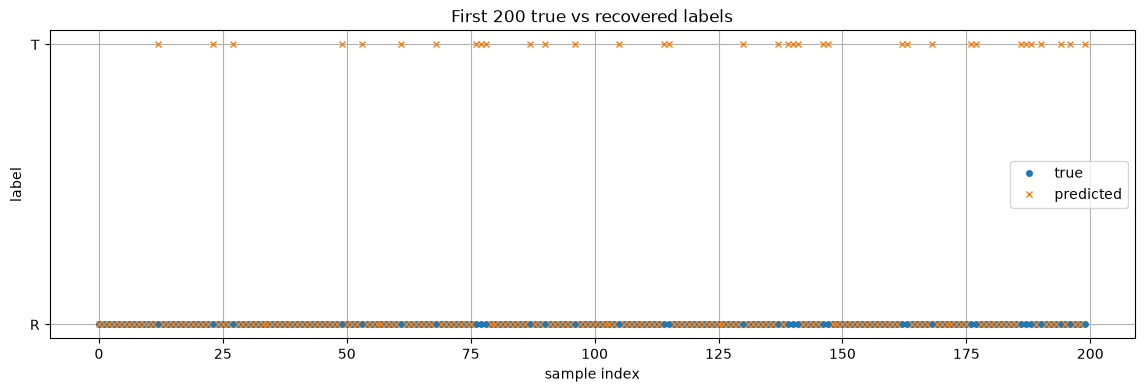

In [13]:
true_labels = onehot_to_labels(attack_onehot_test)
pred_labels = recovered_labels

n = min(200, len(true_labels))
label_to_num = {label: i for i, label in enumerate(label_map)}

true_nums = [label_to_num[label] for label in true_labels[:n]]
pred_nums = [label_to_num[label] for label in pred_labels[:n]]

plt.figure(figsize=(14, 4))
plt.plot(true_nums, label='true', marker='o', linestyle='None', markersize=4)
plt.plot(pred_nums, label='predicted', marker='x', linestyle='None', markersize=4)
plt.yticks(range(len(label_map)), label_map)
plt.xlabel('sample index')
plt.ylabel('label')
plt.title(f'First {n} true vs recovered labels')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

def evaluate_model(y_true, y_pred, title):
    accuracy = accuracy_score(y_true, y_pred)
    weighted_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    weighted_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print('\n' + '=' * 70)
    print(title)
    print('=' * 70)
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Weighted precision: {weighted_precision:.4f}')
    print(f'Weighted recall: {weighted_recall:.4f}')
    print(f'Weighted F1 score: {weighted_f1:.4f}')
    print()

    print('Classification report:')
    print(classification_report(
        y_true, y_pred,
        labels=label_map,
        target_names=label_map,
        zero_division=0,
        digits=2
    ))

    cm = confusion_matrix(y_true, y_pred, labels=label_map)
    print('Confusion matrix:')
    print(pd.DataFrame(cm, index=label_map, columns=label_map))
    print()

    tps = np.diag(cm)
    fps = cm.sum(axis=0) - tps
    fns = cm.sum(axis=1) - tps
    tns = cm.sum() - (tps + fps + fns)

    fpr = np.divide(
        fps, fps + tns,
        out=np.zeros_like(fps, dtype=float),
        where=(fps + tns) != 0
    )
    fnr = np.divide(
        fns, fns + tps,
        out=np.zeros_like(fns, dtype=float),
        where=(fns + tps) != 0
    )

    print('False positive rate per class:')
    for label, rate in zip(label_map, fpr):
        print(f'  {label}: {rate:.4f}')

    print('\nFalse negative rate per class:')
    for label, rate in zip(label_map, fnr):
        print(f'  {label}: {rate:.4f}')

# ------------------------------------------------------------
# Evaluation 1: BALANCED training -> ORIGINAL test set
# ------------------------------------------------------------
y_true_original = onehot_to_labels(attack_onehot_test)
y_pred_original = onehot_to_labels(model.predict(windows_test, verbose=0))

evaluate_model(
    y_true_original,
    y_pred_original,
    'BALANCED TRAINING -> ORIGINAL TEST SET'
)

# ------------------------------------------------------------
# Create a BALANCED COPY of the test set
# ------------------------------------------------------------
# The original windows_test and attack_onehot_test are NOT modified.

test_labels = np.argmax(attack_onehot_test, axis=1)
test_classes, test_counts = np.unique(test_labels, return_counts=True)
test_minority_count = test_counts.min()

balanced_test_indices = np.concatenate([
    np.random.default_rng(42).choice(
        np.where(test_labels == cls)[0],
        size=test_minority_count,
        replace=False
    )
    for cls in test_classes
])

rng_test = np.random.default_rng(42)
rng_test.shuffle(balanced_test_indices)

windows_test_balanced = windows_test[balanced_test_indices]
attack_onehot_test_balanced = attack_onehot_test[balanced_test_indices]

print('\nOriginal test class counts:')
print(dict(zip(test_classes, test_counts)))
print('Balanced test class counts:')
print(dict(zip(*np.unique(np.argmax(attack_onehot_test_balanced, axis=1), return_counts=True))))
print('Balanced test shape:', windows_test_balanced.shape)

# ------------------------------------------------------------
# Evaluation 2: BALANCED training -> BALANCED test set
# ------------------------------------------------------------
y_true_balanced = onehot_to_labels(attack_onehot_test_balanced)
y_pred_balanced = onehot_to_labels(model.predict(windows_test_balanced, verbose=0))

evaluate_model(
    y_true_balanced,
    y_pred_balanced,
    'BALANCED TRAINING -> BALANCED TEST SET'
)



BALANCED TRAINING -> ORIGINAL TEST SET
Accuracy: 0.8057
Weighted precision: 0.9900
Weighted recall: 0.8057
Weighted F1 score: 0.8843

Classification report:
              precision    recall  f1-score   support

           R       1.00      0.81      0.89    716191
           T       0.04      0.86      0.07      6341

    accuracy                           0.81    722532
   macro avg       0.52      0.83      0.48    722532
weighted avg       0.99      0.81      0.88    722532

Confusion matrix:
        R       T
R  576714  139477
T     883    5458

False positive rate per class:
  R: 0.1393
  T: 0.1947

False negative rate per class:
  R: 0.1947
  T: 0.1393

Original test class counts:
{0: 716191, 1: 6341}
Balanced test class counts:
{0: 6341, 1: 6341}
Balanced test shape: (12682, 8, 10)

BALANCED TRAINING -> BALANCED TEST SET
Accuracy: 0.8370
Weighted precision: 0.8378
Weighted recall: 0.8370
Weighted F1 score: 0.8369

Classification report:
              precision    recall  f1-sc

In [15]:
hello()

import os
from tensorflow import keras

os.makedirs("saved_models", exist_ok=True)
model.save(os.path.join("saved_models", "HCRL_model_2.h5"))
print("Saved model to saved_models/HCRL_model_2.h5")

NameError: name 'hello' is not defined

In [ ]:
import tensorflow_model_optimization as tfmot

prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

pruning_params = {
    'pruning_schedule':
        tfmot.sparsity.keras.PolynomialDecay(
            initial_sparsity=0.0,
            final_sparsity=0.5,
            begin_step=0,
            end_step=2000
        )
}

pruned_model = prune_low_magnitude(
    model,
    pruning_params
)

pruned_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep()
]

# IMPORTANT: train pruning on the balanced TRAINING set.
# Do not use windows_test here because that would leak test data.
history = pruned_model.fit(
    windows_balanced,
    attack_onehot_balanced,
    epochs=5,
    batch_size=2000,
    callbacks=callbacks
)


ValueError: `prune_low_magnitude` can only prune an object of the following types: keras.models.Sequential, keras functional model, keras.layers.Layer, list of keras.layers.Layer. You passed an object of type: Sequential.

In [ ]:
# ------------------------------------------------------------
# Evaluate the pruned model on ORIGINAL and BALANCED test sets
# ------------------------------------------------------------
loss_p, accuracy_p = pruned_model.evaluate(
    windows_test, attack_onehot_test, verbose=0
)
print(f'Test loss (original test set): {loss_p:.4f}')
print(f'Test accuracy (original test set): {accuracy_p:.4f}')

y_pred_p_original = onehot_to_labels(pruned_model.predict(windows_test, verbose=0))
y_true_p_original = onehot_to_labels(attack_onehot_test)

evaluate_model(
    y_true_p_original,
    y_pred_p_original,
    'PRUNED MODEL: BALANCED TRAINING -> ORIGINAL TEST SET'
)

y_pred_p_balanced = onehot_to_labels(
    pruned_model.predict(windows_test_balanced, verbose=0)
)
y_true_p_balanced = onehot_to_labels(attack_onehot_test_balanced)

evaluate_model(
    y_true_p_balanced,
    y_pred_p_balanced,
    'PRUNED MODEL: BALANCED TRAINING -> BALANCED TEST SET'
)
